Equations and methods derived from:
>Winters K.B. (1995) _"Available potential energy and mixing in density-stratified fluids"_

Partitions the potential energy into background potential energy Eb and available potential energy Ea (sometimes noted APE in other publications).
***
**Background potential energy (Eb)** is definied as the minimum potential energy attainable through adiabatic (no change of temperature) redistribution of /rho into a reference state.

**Available potential energy (Ea/APE)** is the potential energy released in an adiabatic transition from the lake's state to the reference state.

**Total potential energy (Ep)** is the sum of background potential energy and available potential energy.

In [1]:
import sys
import os
from multiprocessing.pool import ExceptionWithTraceback

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from numpy.f2py.auxfuncs import throw_error

sys.path.append('../..//')
from utils_mitgcm import open_mitgcm_ds_from_config
import pylake

/home/leroquan@eawag.wroot.emp-eaw.ch/miniconda3/envs/horizontal_structures/lib/python3.11/site-packages/pylake/pylake.py:3: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
model = 'geneva_2025'
mitgcm_config, ds = open_mitgcm_ds_from_config('../../config.json', model)

In [3]:
folder_path = os.path.dirname(mitgcm_config['datapath'])
output_folder = os.path.join(folder_path, "seiche_analysis", "potential_energy")
os.makedirs(output_folder, exist_ok=True)

In [4]:
grid_resolution = 100
ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

In [5]:
mask = ds.THETA.isel(time=0).values != 0

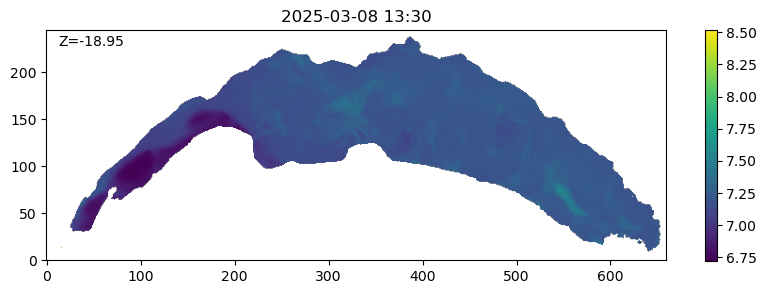

In [6]:
plt.figure(figsize=(10, 3))
zz = 25
tt = 24 * 8 - 10
plt.imshow(ds.THETA.isel(time=tt, Z=zz).where(mask[zz], np.nan))
plt.text(0.02, 0.98, f'Z={ds.Z.isel(Z=zz).values:.2f}', ha='left', va='top', transform=plt.gca().transAxes)
t = ds.time.isel(time=tt).values
plt.title(np.datetime_as_string(t, unit='m').replace('T', ' '))
plt.gca().invert_yaxis()
plt.colorbar()


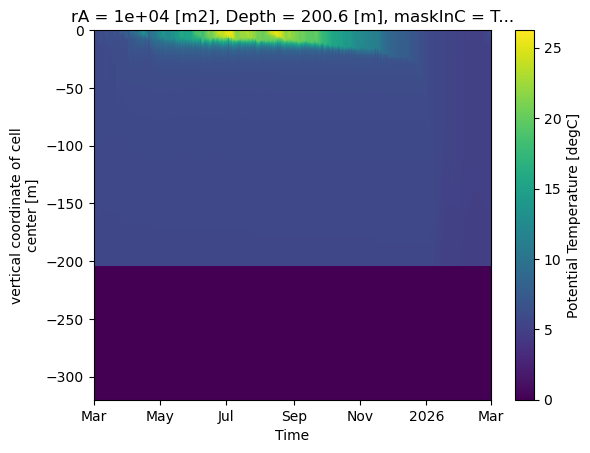

In [8]:
z_index= 15
xc_index = 25
yc_index = 40

ds['THETA'].isel(XC=xc_index,YC=yc_index).plot(y='Z')

# Get density

In [7]:
g = 9.81

In [8]:
ds['theta_nan'] = ds['THETA'].where(mask, np.nan)

In [9]:
rho = pylake.dens0(s=0.2, t=ds.theta_nan).astype(np.float64)

# Get Total Potential Energy Epot

In [10]:
ref_z = ds.Zp1.values[-1]
z = ds.Z - ref_z

In [11]:
volume = (ds.drF * ds.rA).where(mask, np.nan).astype(np.float64)

In [12]:
Epot = g * rho * z * volume.astype(np.float64)

In [13]:
Epot_sum = Epot.sum(dim=['XC', 'YC', 'Z'])

In [14]:
df_Epot = Epot_sum.to_dataframe(name='Epot_tot')['Epot_tot']

In [15]:
df_Epot.reset_index().to_csv(os.path.join(output_folder, "EPtot_KBWinters1995.csv"))

<Axes: xlabel='time'>

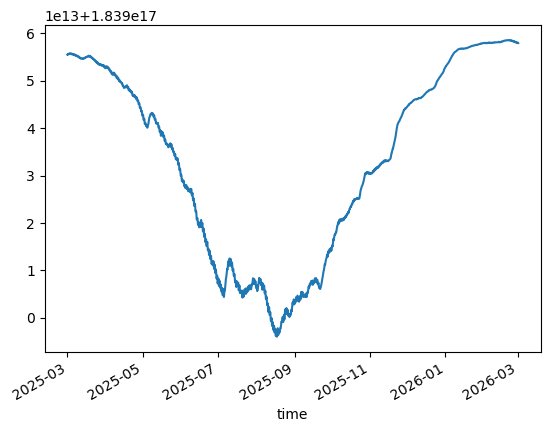

In [16]:
df_Epot.plot()

# Get Background Potential Energy

In [17]:
def volume_to_depth(V_query, V_cum_lake, z_grid):
    """
    Map cumulative volume to depth using bathymetry.

    You must precompute:
        V(z) from bathymetry
    then invert it.
    """

    return np.interp(V_query, V_cum_lake, z_grid)

In [18]:
def compute_background_potential_energy(time_index, rho, volume_flat, z_flat, mask_flat):

    v_cum_lake = np.cumsum(volume_flat[mask_flat])
    rho_arr = np.asarray(rho.isel(time=time_index)).ravel()

    rho_arr = rho_arr[mask_flat]
    # -------------------------
    # Sort densities (reference state)
    # -------------------------
    idx = np.argsort(rho_arr) #sorted from higher to lower
    rho_sorted = rho_arr[idx]
    V_sorted = volume_flat[mask_flat][idx]
    # -------------------------
    # Build sorted vertical positions
    # -------------------------
    # cumulative volume coordinate
    V_cum = np.cumsum(V_sorted)

    # assign depths assuming monotonic mapping z(V)
    # (you must provide or precompute from bathymetry)
    z_sorted = volume_to_depth(V_cum, v_cum_lake, z_flat[mask_flat])

    # -------------------------
    # 4. Sorted potential energy
    # -------------------------
    E_background = rho_sorted * g * z_sorted * V_sorted

    return E_background, z_sorted

In [19]:
xc_index = 25
yc_index = 40

In [20]:
time_index = 24 * 7 - 10
volume_flat = np.asarray(volume).astype(np.float64).ravel()
z_flat = np.repeat(np.asarray(z), volume.sizes["YC"] * volume.sizes["XC"])
mask_flat = (ds.THETA.isel(time=0).values != 0).ravel()
Eb_snap, z_sorted = compute_background_potential_energy(time_index, rho, volume_flat, z_flat, mask_flat)


In [21]:
idx_layer = z_sorted==z_sorted[0]
Eb_snap[z_sorted==z_sorted[0]]

array([2.25625440e+10, 2.96545260e+10, 2.19035547e+10, ...,
       1.93941367e+10, 1.61617818e+10, 1.76995048e+10], shape=(52607,))

In [22]:
Eb_snap/1e8

array([225.62544026, 296.5452597 , 219.03554735, ...,   3.0341883 ,
         2.70420192,   2.46258992], shape=(4005185,))

In [23]:
Epot_sum.isel(time=time_index).values/1e8

np.float64(1839553614.3107557)

In [ ]:
Eb = []
for i in range(len(ds.time)):
    Eb_temp, z_sorted = compute_background_potential_energy(i, rho, volume_flat, z_flat, mask_flat)
    Eb.append(np.sum(Eb_temp))

In [ ]:
if isinstance(df_Epot, pd.Series):
    df_Epot = df_Epot.to_frame(name="Epot_tot")

df_Epot["Eb"] = pd.Series(Eb, index=df_Epot.index)


In [ ]:
df_Epot['APE'] = df_Epot['Epot_tot'] - df_Epot['Eb']

<Axes: xlabel='time'>

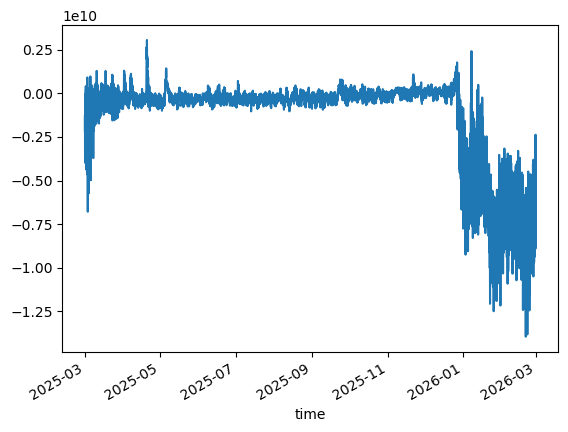

In [ ]:
df_Epot['APE'].plot()

In [ ]:
df_Epot.reset_index().to_csv(os.path.join(output_folder, "EP_KBWinters1995.csv"))